In [1]:
import pandas as pd
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import os

In [2]:
symptoms_list = [
    'creamyDischarge', 'anxious', 'everythingIsFine', 'gifts', 'illness',
    'annoyed', 'lowerBackPain', 'curdledDischarge', 'heavyMenstruation',
    'confused', 'nightWithoutSleep', 'masturbation', 'emergencyContraceptives',
    'pullsInStomach', 'wateryDischarge', 'bloodyDischarge', 'crying', 'weakness',
    'clots', 'leaveMeAlone', 'playful', 'constipation', 'sexWithoutProtection',
    'enthusiastic', 'candy', 'sad', 'spottyDischarge', 'didNotDrinkContraceptives',
    'mucousDischarge', 'swelling', 'calm', 'tired', 'apathy', 'sexWithProtection',
    'sensitiveBreasts', 'energetic', 'nausea', 'drowsy', 'chills', 'acne',
    'headache', 'moodSwings', 'drankOralContraceptives', 'alcohol', 'insomnia',
    'aLotOfMoney', 'stickyDischarge', 'increasedAppetite', 'bloating',
    'strongDesireSex', 'travel', 'stressed', 'climateChange', 'joyful',
    'moderateMenstruation', 'diarrhea', 'scantyMenstruation', 'fever', 'love'
]
phases = {
    'Месячные': 'periods',
    'Фолликулярная': 'follicular_phases',
    'Овуляция': 'ovulation_phases',
    'Лютеиновая': 'luteal_phases',
    'ПМС': 'pms_phases'
}

### Предобработка данных

In [ ]:
def group_periods(periods_str):

    dates = [datetime.strptime(date_str[:10], "%Y-%m-%d") for date_str in json.loads(periods_str)]

    cycles = []
    current_cycle = []

    for date in dates:
        if current_cycle and (date - current_cycle[-1]).days == 1:
            current_cycle.append(date)
        else:
            if current_cycle:
                cycles.append(current_cycle)
            current_cycle = [date] 
    
    if current_cycle:  # Добавляем последний цикл
        cycles.append(current_cycle)
    
    
    return cycles

def get_age_cat(birthday):

    if pd.isna(birthday):
        return None
    
    if isinstance(birthday, str):
        try:
            birthday = datetime.strptime(birthday[:10], "%Y-%m-%d")
        except ValueError:
            return None

    today = datetime.today()
    age = today.year - birthday.year - ((today.month, today.day) < (birthday.month, birthday.day))

    if age < 13:
        return "До 13 лет"
    elif age <= 18:
        return "13-18 лет"
    elif age <= 25:
        return "19-25 лет"
    elif age <= 35:
        return "26-35 лет"
    elif age <= 45:
        return "36-45 лет"
    else:
        return "46+ лет"
     
def calculate_phase_periods(row):
    cycles = row["periods"]

    follicular_list = []
    ovulation_list = []
    luteal_list = []
    pms_list = []

    percentages = [22, 26, 37, 15]


    for i, cycle in enumerate(cycles[:-1]):
        period_start = cycle[0]
        period_end = cycle[-1]
        cycle_end = cycles[i + 1][0]
        
        # Вычисление длины цикла
        cycle_len = (cycle_end - period_start).days

        # Проверка на корректность длины цикла
        if 13 < cycle_len < 50:
            # Создание списка всех дат между окончанием периода и концом цикла
            dates = pd.date_range(period_end + timedelta(days=1), cycle_end - timedelta(days=1)) \
                        .strftime('%Y-%m-%d').tolist()
            total_days = len(dates)
            start_date = dates[0]

            intervals = []

            # Разбиение на интервалы по процентам
            for percentage in percentages:
                interval_days = total_days * percentage / 100
                start_dt = datetime.strptime(start_date, "%Y-%m-%d")
                end_dt = start_dt + timedelta(days=interval_days)
                last_dt = datetime.strptime(dates[-1], "%Y-%m-%d")
                
                if end_dt > last_dt:
                    end_dt = last_dt

                end_date = end_dt.strftime("%Y-%m-%d")
                intervals.append((start_date, end_date))
                start_date = (end_dt + timedelta(days=1)).strftime("%Y-%m-%d")


            follicular_list.append(intervals[0])
            ovulation_list.append(intervals[1])
            luteal_list.append(intervals[2])
            pms_list.append(intervals[3])

    return pd.Series({
        "follicular_phases": follicular_list,
        "ovulation_phases": ovulation_list,
        "luteal_phases": luteal_list,
        "pms_phases": pms_list
    })

def create_intervals(date_list):
    intervals = []
    for dates in date_list:
        start_date = dates[0].strftime('%Y-%m-%d')
        end_date = dates[-1].strftime('%Y-%m-%d')
        intervals.append((start_date, end_date))
    return intervals

def is_date_in_interval(date, intervals):
    for start_date, end_date in intervals:
        start_date = datetime.strptime(start_date, '%Y-%m-%d')
        end_date = datetime.strptime(end_date, '%Y-%m-%d')
        if start_date <= date <= end_date:
            return True
    return False

def process_row(row, symptoms_list, phases):
    result = {f'{symptom}_{phase}': 0 for symptom in symptoms_list for phase in phases}

    for phase in phases:
        result[phase] = 0
    
    symptom_days = {phase: set() for phase in phases}

    symptoms_data = json.loads(row['symptoms_data'])
    
    phase_intervals = {phase_name: row[column_name] for phase_name, column_name in phases.items()}


    for symptom_entry in symptoms_data:
        date_str = symptom_entry['date']
        date = datetime.strptime(date_str[:10], '%Y-%m-%d')
        symptoms = symptom_entry['symptoms']

        for phase_name, intervals in phase_intervals.items():
            if is_date_in_interval(date, intervals):
                for symptom in symptoms:
                    result[f'{symptom}_{phase_name}'] += 1
                symptom_days[phase_name].add(date_str[:10])
    
    for phase in phases:
        result[phase] = len(symptom_days[phase])

    return pd.Series(result)

In [ ]:
column_names = ["id", "birthday", "periods_data", "symptoms_data"] 
df = pd.read_csv("rawData.csv", names=column_names, header=None)
df = df.dropna()

df = df[df["periods_data"].apply(lambda x: len(x) > 2)]
df = df[df["symptoms_data"].apply(lambda x: len(x) > 2)]

df["periods"] = df["periods_data"].apply(group_periods)

df = df[df["periods"].apply(len) > 2]

df["age_cat"] = df["birthday"].apply(get_age_cat)
df = df.drop("birthday", axis=1)

In [ ]:
df_final = df.copy()
df_final = pd.concat([df_final, df_final.apply(calculate_phase_periods, axis=1)], axis=1)
df_final['periods'] = df_final['periods'].apply(create_intervals)

In [ ]:
symptoms_flags = df_final.apply(lambda row: process_row(row, symptoms_list, phases), axis=1)
df = pd.concat([df_final, symptoms_flags], axis=1)

In [ ]:
df.to_csv('happy_happy_happy.csv')

## Расчет групповых вероятностей

In [6]:
df = pd.read_csv('happy_happy_happy.csv')

In [7]:
phase_symptom_columns = [f'{symptom}_{phase}' for symptom in symptoms_list for phase in phases]

grouped = df.groupby('age_cat')

result = pd.DataFrame(columns=['age_cat'] + phase_symptom_columns)

rows = []
for age_cat, group in grouped:
    row = {'age_cat': age_cat}
    for column in phase_symptom_columns:
        row[column] = (group[column] > 0).sum()
    rows.append(row)

result = pd.DataFrame(rows, columns=['age_cat'] + phase_symptom_columns)

result.to_csv('count_symptoms.csv', index=False)

In [8]:
phase_columns = [f'{phase}' for phase in phases]

grouped = df.groupby('age_cat')

result = pd.DataFrame(columns=['age_cat'] + phase_columns)

rows = []
for age_cat, group in grouped:
    row = {'age_cat': age_cat}
    for column in phase_columns:
        row[column] = (group[column] > 0).sum()
    rows.append(row)

result = pd.DataFrame(rows, columns=['age_cat'] + phase_columns)

result.to_csv('count_days.csv', index=False)

In [9]:
count_symptoms = pd.read_csv('count_symptoms.csv')
count_days = pd.read_csv('count_days.csv')

phase_symptom_columns = [f'{symptom}_{phase}' for symptom in symptoms_list for phase in phases]

group_probabilities = {}

for index, row in count_symptoms.iterrows():
    age_cat = row['age_cat']
    count_days_row = count_days[count_days['age_cat'] == age_cat]
    
    if not count_days_row.empty:
        count_days_row = count_days_row.iloc[0]
        
        for column in phase_symptom_columns:
            symptom, phase = column.split('_')
            phase_count = count_days_row[phase]
            
            if phase_count > 0:
                probability = row[column] / phase_count
            else:
                probability = 0
            
            key = (age_cat, phase)
            if key not in group_probabilities:
                group_probabilities[key] = {}
            group_probabilities[key][symptom] = round(probability, 2)


#### Сохранения картинок с гистограммами для групповых данных

In [ ]:
# os.makedirs('histograms_new', exist_ok=True)


# for phase in phases:
#     phase_probabilities = {key: value for key, value in group_probabilities.items() if key[1] == phase}
    
#     num_plots = len(phase_probabilities)
#     cols = 3
#     rows = (num_plots // cols) + (num_plots % cols > 0)
    
#     fig, axes = plt.subplots(rows, cols, figsize=(30, 14))
#     axes = axes.flatten()
    
#     for ax, (key, symptom_probs) in zip(axes, phase_probabilities.items()):
#         age_cat, _ = key
#         symptoms = list(symptom_probs.keys())
#         probs = list(symptom_probs.values())
        
#         ax.bar(symptoms, probs, color='skyblue')
#         ax.set_xlabel('Симптомы')
#         ax.set_ylabel('Вероятности')
#         ax.set_title(f'{age_cat}')
#         ax.set_xticklabels(symptoms, rotation=90)
    
#     for ax in axes[num_plots:]:
#         fig.delaxes(ax)
    
#     plt.tight_layout()
    
#     filename = f'histograms_new/{phase}.png'
#     plt.savefig(filename)
#     plt.close()

# print("Гистограммы сохранены в папке 'histograms'.")

### Индивидуальные предсказания

In [10]:
def calculate_probabilities(user_data, symptoms_list, phases):
    age_cat = user_data['age_cat']
    return {
        (age_cat, phase): {
            symptom: round(user_data[f'{symptom}_{phase}'] / user_data[phase], 2) if user_data[phase] > 0 else 0
            for symptom in symptoms_list
        }
        for phase in phases
    }


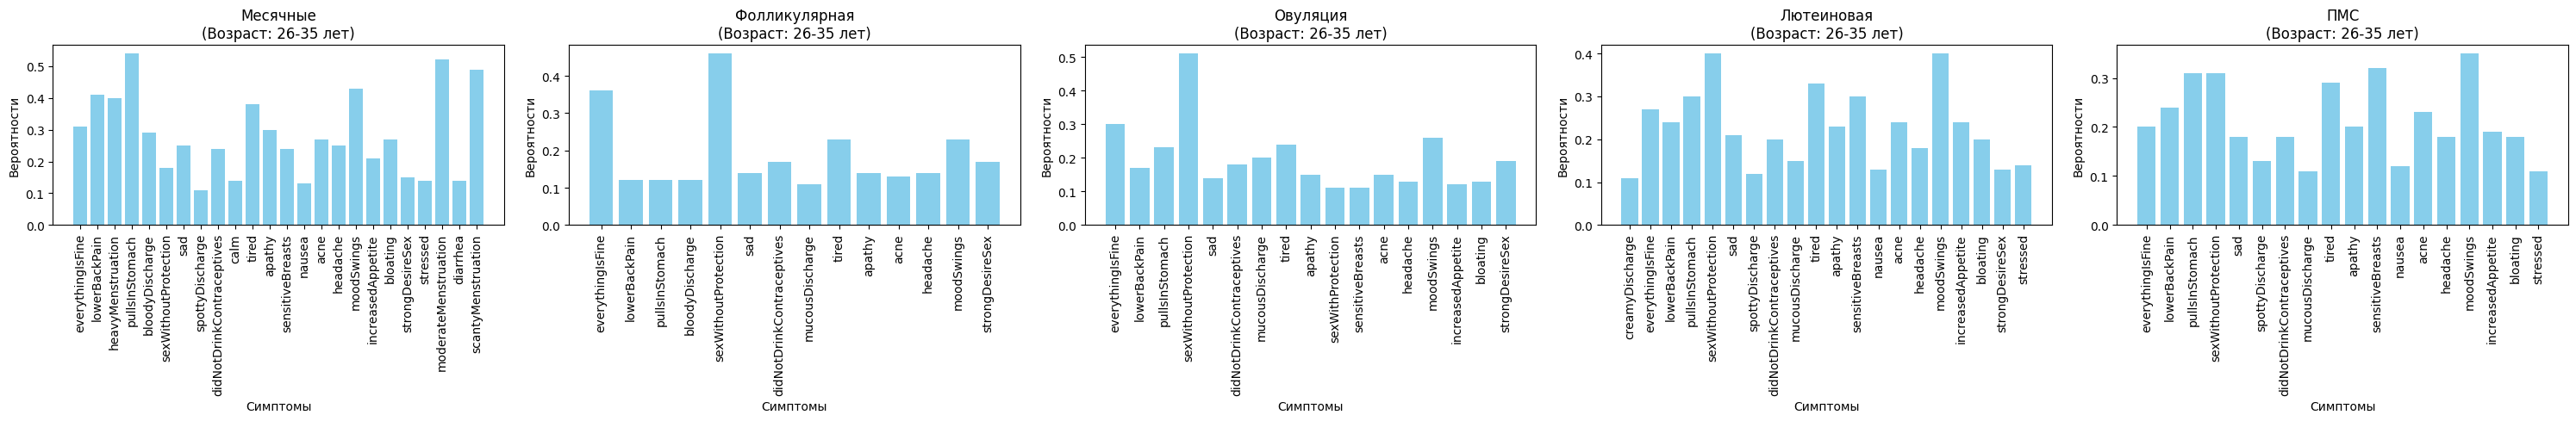

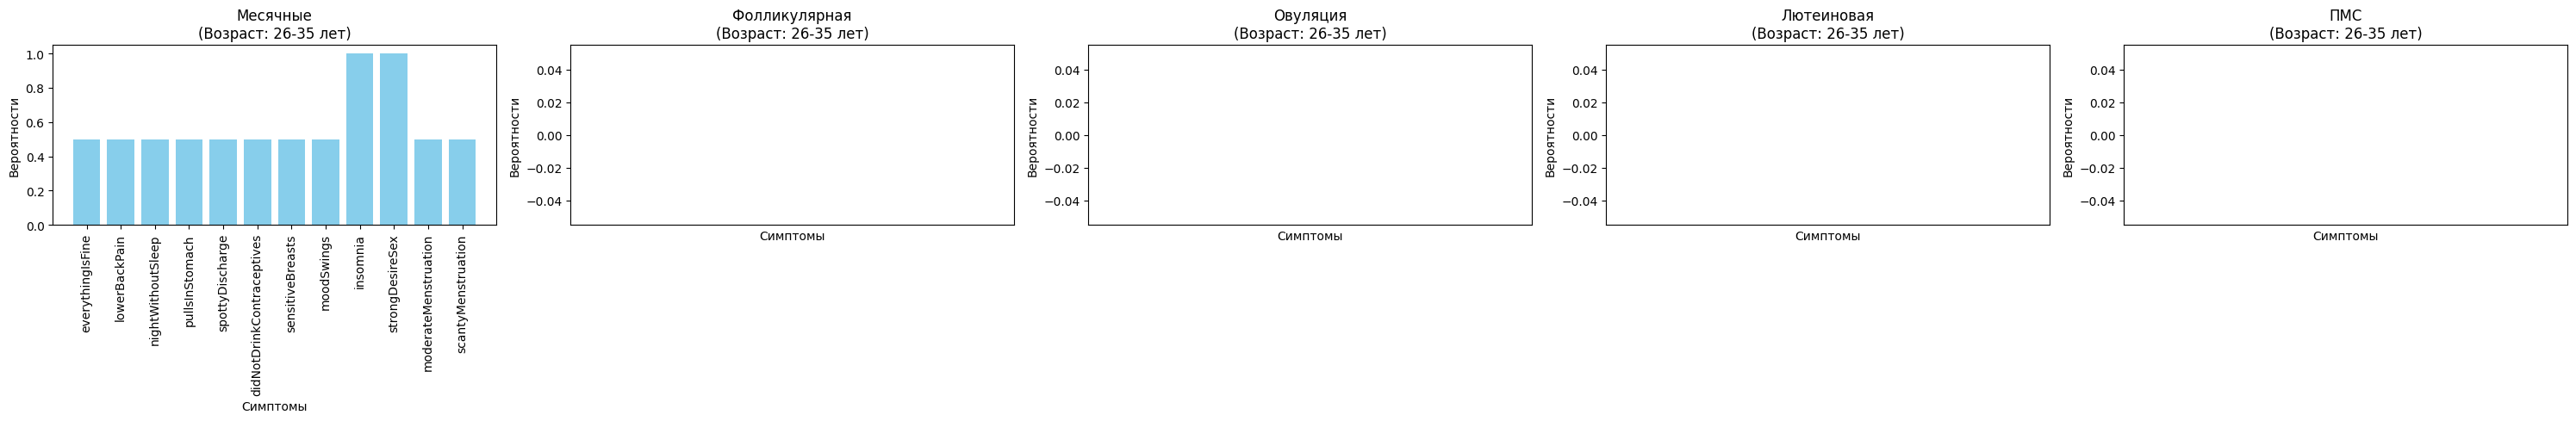

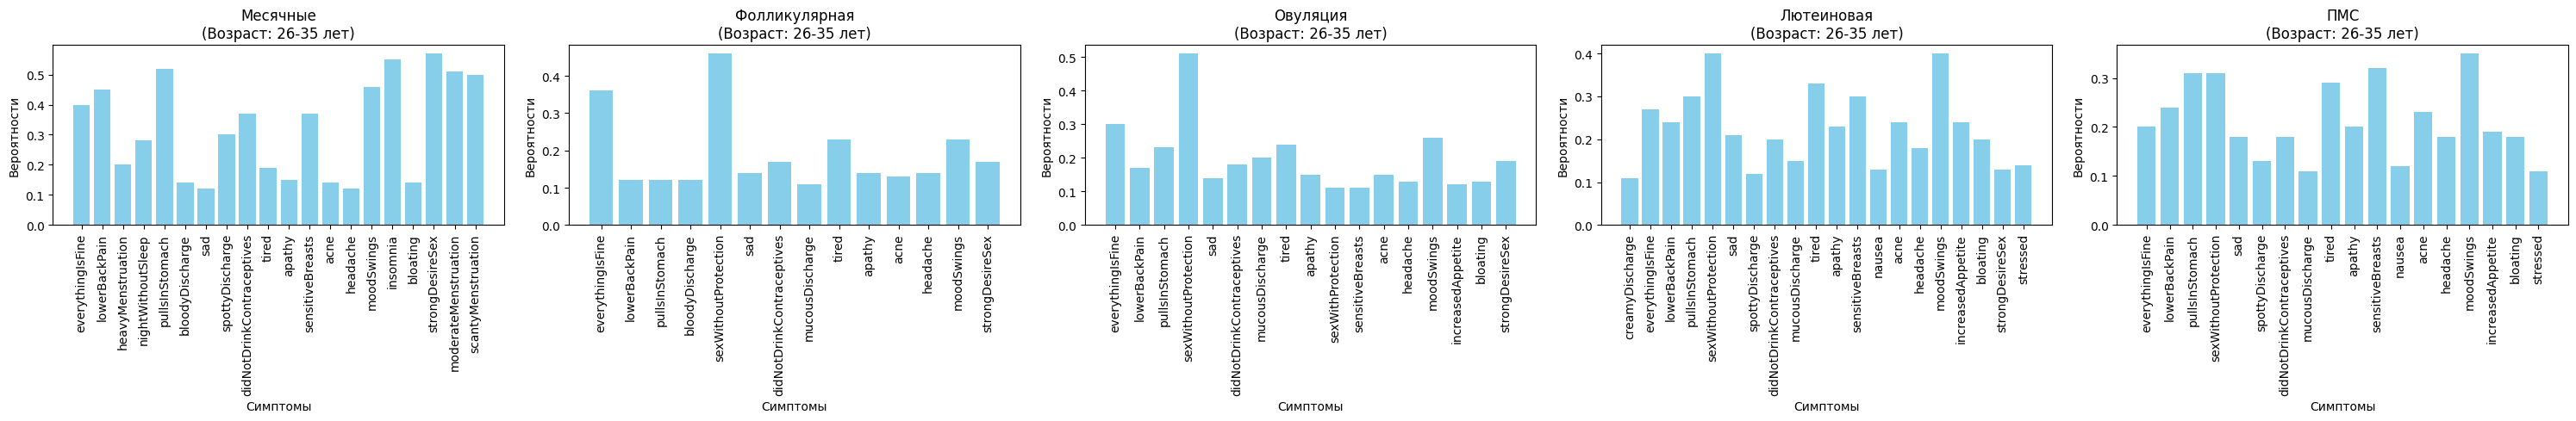

Вероятности групповых симптомов для возрастной группы пользователя:
{('26-35 лет', 'Месячные'): {'creamyDischarge': 0.02, 'anxious': 0.01, 'everythingIsFine': 0.31, 'gifts': 0.0, 'illness': 0.07, 'annoyed': 0.03, 'lowerBackPain': 0.41, 'curdledDischarge': 0.01, 'heavyMenstruation': 0.4, 'confused': 0.09, 'nightWithoutSleep': 0.05, 'masturbation': 0.07, 'emergencyContraceptives': 0.01, 'pullsInStomach': 0.54, 'wateryDischarge': 0.04, 'bloodyDischarge': 0.29, 'crying': 0.0, 'weakness': 0.0, 'clots': 0.0, 'leaveMeAlone': 0.0, 'playful': 0.02, 'constipation': 0.05, 'sexWithoutProtection': 0.18, 'enthusiastic': 0.01, 'candy': 0.0, 'sad': 0.25, 'spottyDischarge': 0.11, 'didNotDrinkContraceptives': 0.24, 'mucousDischarge': 0.09, 'swelling': 0.0, 'calm': 0.14, 'tired': 0.38, 'apathy': 0.3, 'sexWithProtection': 0.05, 'sensitiveBreasts': 0.24, 'energetic': 0.04, 'nausea': 0.13, 'drowsy': 0.0, 'chills': 0.1, 'acne': 0.27, 'headache': 0.25, 'moodSwings': 0.43, 'drankOralContraceptives': 0.06, 'alc

In [12]:
# Выбор случайного пользователя
user_data = df.sample(n=1).iloc[0]

# Определенный пользователь
# id = 'fa0d0c26-9d29-4198-a98b-f03ae6bdc6f6'
# user_data = df[df['id'] == id].iloc[0]

probabilities_i = calculate_probabilities(user_data, symptoms_list, phases)

# Чем больше K, тем больше вес у групповых вероятностей
K = 2

prob_final = {}
for phase in phases:
    key = (user_data['age_cat'], phase)
    if key in probabilities_i and key in group_probabilities:
        prob_final[key] = {}
        for symptom in symptoms_list:
            Pi_s = probabilities_i[key][symptom]
            Pg_s = group_probabilities[key][symptom]
            n_s = user_data[phase]
            Wi_s = n_s / (n_s + K)
            Wg_s = 1 - Wi_s
            Ptotal_s = (Wi_s * Pi_s) + (Wg_s * Pg_s)
            prob_final[key][symptom] = round(Ptotal_s, 2)
            

def plot_probabilities(prob_dict, threshold, figsize=(30, 5), num_phases=5, cols=5):
    rows = (num_phases // cols) + (num_phases % cols > 0)
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], figsize[1] * rows))
    axes = axes.flatten() 

    for ax, ((age_cat, phase), symptom_probs) in zip(axes, prob_dict.items()):
        filtered = {symptom: prob for symptom, prob in symptom_probs.items() if prob > threshold}
        symptoms = list(filtered.keys())
        probs = list(filtered.values())

        ax.bar(symptoms, probs, color='skyblue')
        ax.set_xlabel('Симптомы')
        ax.set_ylabel('Вероятности')
        ax.set_title(f'{phase}\n(Возраст: {age_cat})')
        ax.set_xticks(range(len(symptoms)))
        ax.set_xticklabels(symptoms, rotation=90)

    for ax in axes[len(prob_dict):]:
        ax.bar([], [])
        ax.set_xlabel('Симптомы')
        ax.set_ylabel('Вероятности')
        ax.set_title('Нет данных')
        ax.set_xticklabels([])

    plt.tight_layout()
    plt.show()



user_age = user_data['age_cat']
group_probabilities_filtered = {k: v for k, v in group_probabilities.items() if k[0] == user_age}


plot_probabilities(group_probabilities_filtered, threshold=0.1, num_phases=5, cols=5)
plot_probabilities(probabilities_i, threshold=0, num_phases=5, cols=5)
plot_probabilities(prob_final, threshold=0.1, num_phases=5, cols=5)

print("Вероятности групповых симптомов для возрастной группы пользователя:")
print(group_probabilities_filtered)
print("\nИндивидуальные вероятности симптомов пользователя:")
print(probabilities_i)
print("\nИтоговые вероятности:")
print(prob_final)
